In [26]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import OneHotEncoder,StandardScaler

In [2]:
df = pd.read_csv("bmw.csv")

**EDA -> Exploratory Data Analysis**

In [3]:
df.head(3)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  object 
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  object 
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  object 
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 758.2+ KB


In [5]:
df.shape

(10781, 9)

In [6]:
df1 = df.copy()

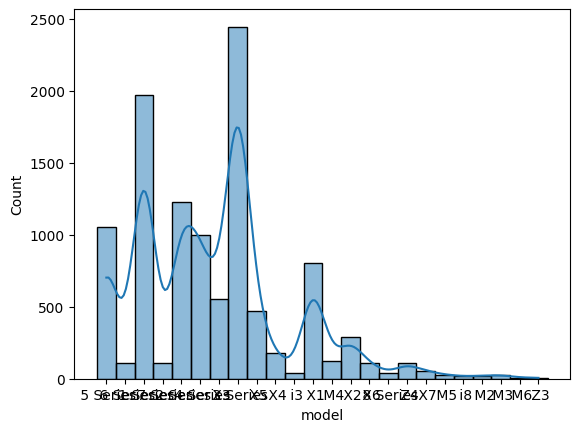

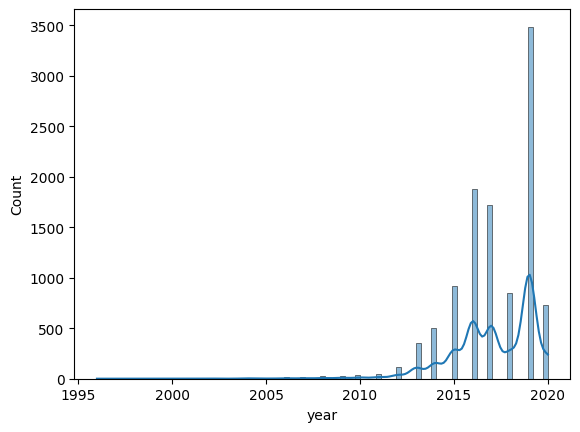

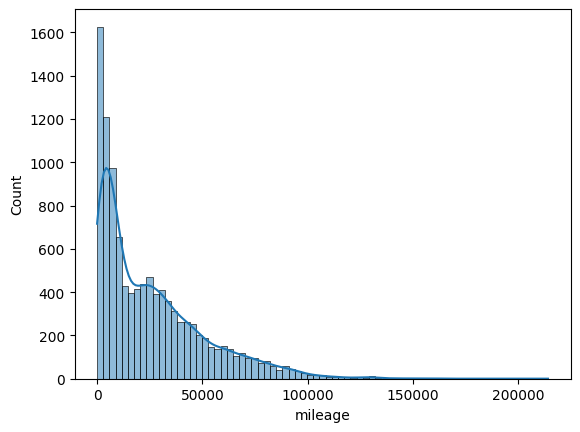

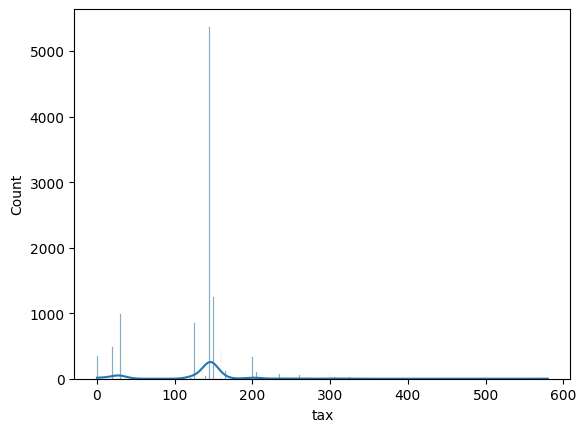

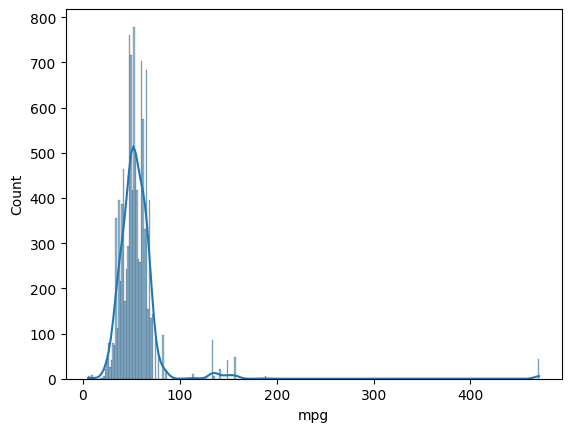

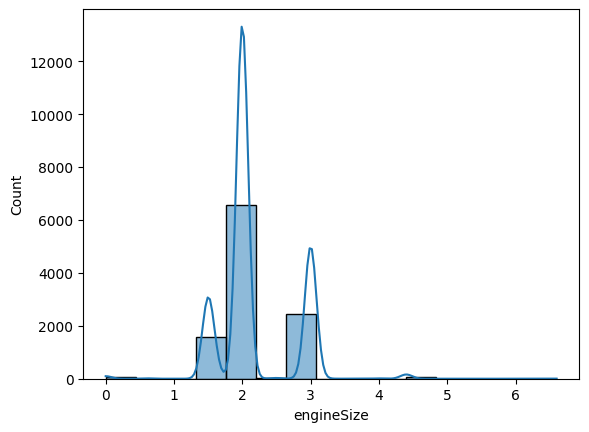

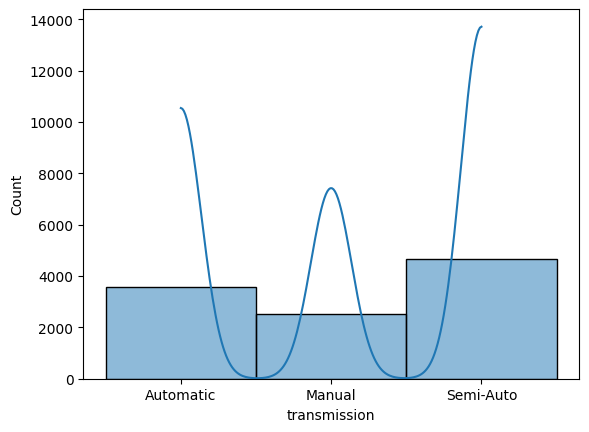

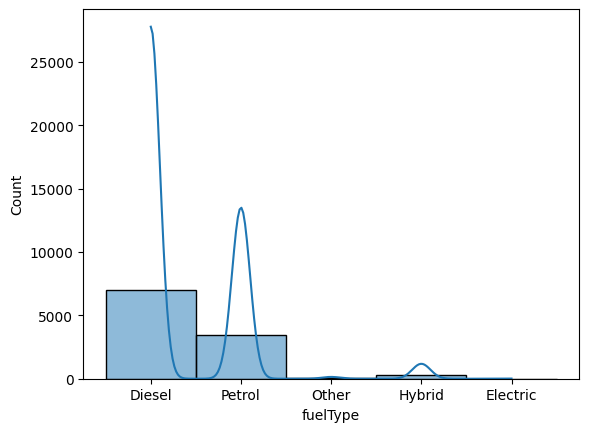

In [7]:
from seaborn.utils import plt
cols = ['model','year','mileage','tax','mpg','engineSize','transmission', 'fuelType']

for col in cols:
  sns.histplot(data=df1,x=col,kde=True)
  plt.show()


In [8]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000
mean,2017.078935,22733.408867,25496.986550,131.702068,56.399035,2.167767
std,2.349038,11415.528189,25143.192559,61.510755,31.336958,0.552054
min,1996.000000,1200.000000,1.000000,0.000000,5.500000,0.000000
25%,2016.000000,14950.000000,5529.000000,135.000000,45.600000,2.000000
50%,2017.000000,20462.000000,18347.000000,145.000000,53.300000,2.000000
75%,2019.000000,27940.000000,38206.000000,145.000000,62.800000,2.000000
max,2020.000000,123456.000000,214000.000000,580.000000,470.800000,6.600000


<Axes: >

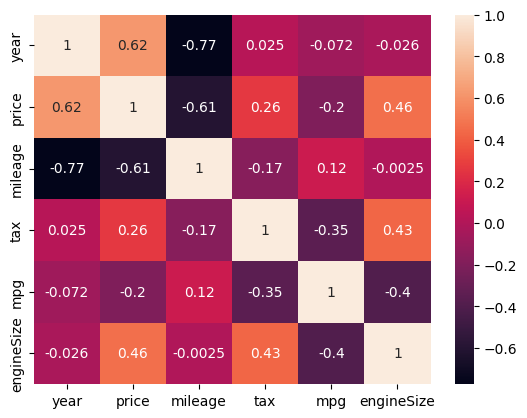

In [9]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [10]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


In [11]:
df['transmission'].unique()

array(['Automatic', 'Manual', 'Semi-Auto'], dtype=object)

In [12]:
df['fuelType'].unique()


array(['Diesel', 'Petrol', 'Other', 'Hybrid', 'Electric'], dtype=object)

In [13]:
df['model'].unique()

array([' 5 Series', ' 6 Series', ' 1 Series', ' 7 Series', ' 2 Series',
       ' 4 Series', ' X3', ' 3 Series', ' X5', ' X4', ' i3', ' X1', ' M4',
       ' X2', ' X6', ' 8 Series', ' Z4', ' X7', ' M5', ' i8', ' M2',
       ' M3', ' M6', ' Z3'], dtype=object)

In [14]:
ohe = OneHotEncoder()

In [15]:
ohe.fit_transform(df[['transmission','fuelType']])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 21562 stored elements and shape (10781, 8)>

In [16]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


In [17]:
cols = ['mileage','tax','mpg','engineSize']
ss = StandardScaler()
df[cols] = ss.fit_transform(df[cols])

In [18]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,1.653447,Diesel,-0.108963,0.038326,-0.303911
1,6 Series,2018,27000,Automatic,-0.424388,Petrol,0.216199,-0.433982,-0.303911
2,5 Series,2016,16000,Automatic,1.483453,Diesel,0.460070,-0.159533,1.507591
3,1 Series,2017,12750,Automatic,0.046894,Diesel,0.216199,0.510634,-1.209662
4,7 Series,2014,14500,Automatic,0.559104,Diesel,0.460070,-0.191445,1.507591


In [19]:
df['fuelType'] = ohe.fit_transform(df[['fuelType']]).toarray()

In [20]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,1.653447,1.0,-0.108963,0.038326,-0.303911
1,6 Series,2018,27000,Automatic,-0.424388,0.0,0.216199,-0.433982,-0.303911
2,5 Series,2016,16000,Automatic,1.483453,1.0,0.460070,-0.159533,1.507591
3,1 Series,2017,12750,Automatic,0.046894,1.0,0.216199,0.510634,-1.209662
4,7 Series,2014,14500,Automatic,0.559104,1.0,0.460070,-0.191445,1.507591


In [21]:
cols = ['model','year','transmission']
df = pd.get_dummies(df,columns=cols,drop_first=True)

In [22]:
df.head()

,price,mileage,fuelType,tax,mpg,engineSize,model_ 2 Series,model_ 3 Series,model_ 4 Series,model_ 5 Series,...,year_2013,year_2014,year_2015,year_2016,year_2017,year_2018,year_2019,year_2020,transmission_Manual,transmission_Semi-Auto
0,11200,1.653447,1.0,-0.108963,0.038326,-0.303911,False,False,False,True,...,False,True,False,False,False,False,False,False,False,False
1,27000,-0.424388,0.0,0.216199,-0.433982,-0.303911,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,16000,1.483453,1.0,0.460070,-0.159533,1.507591,False,False,False,True,...,False,False,False,True,False,False,False,False,False,False
3,12750,0.046894,1.0,0.216199,0.510634,-1.209662,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,14500,0.559104,1.0,0.460070,-0.191445,1.507591,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [23]:
df.shape

(10781, 55)

In [24]:
df.astype(int)

,price,mileage,fuelType,tax,mpg,engineSize,model_ 2 Series,model_ 3 Series,model_ 4 Series,model_ 5 Series,...,year_2013,year_2014,year_2015,year_2016,year_2017,year_2018,year_2019,year_2020,transmission_Manual,transmission_Semi-Auto
0,11200,1,1,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
1,27000,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,16000,1,1,0,0,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
3,12750,0,1,0,0,-1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,14500,0,1,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10776,19000,0,1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
10777,14600,0,1,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
10778,13100,0,0,1,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,1,0
10779,9930,0,1,-1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [25]:
X = df.drop('price',axis=1)
y = df['price']

In [27]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [30]:
y_pred = lr.predict(X_test)

In [31]:
mse = mean_squared_error(y_test,y_pred)
mse

15826971.808269527

In [32]:
rmse = mse ** 0.5
rmse

3978.3126835719595

In [33]:
y_pred2 = lr.predict(X_train)
mse2 = mean_squared_error(y_train,y_pred2)
mse2

13691718.68668097